# 1. Import library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ExpSineSquared, DotProduct, RationalQuadratic, ConstantKernel
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.compose import TransformedTargetRegressor
from skopt import gp_minimize
from skopt.space import Real
from scipy.optimize import differential_evolution
from scipy.optimize import minimize
from scipy.stats import norm

# 2. Data Inputs

In [2]:
inputs5 = np.array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
       [0.75865295, 0.53651774, 0.65600038, 0.36034155],
       [0.43834987, 0.8043397 , 0.21024527, 0.15129482],
       [0.70605083, 0.53419196, 0.26424335, 0.48208755],
       [0.83647799, 0.19360965, 0.6638927 , 0.78564888],
       [0.68343225, 0.11866264, 0.82904591, 0.56757661],
       [0.55362148, 0.66734998, 0.32380582, 0.81486975],
       [0.35235627, 0.32224153, 0.11697937, 0.47311252],
       [0.15378571, 0.72938169, 0.42259844, 0.44307417],
       [0.46344227, 0.63002451, 0.10790646, 0.9576439 ],
       [0.67749115, 0.35850951, 0.47959222, 0.07288048],
       [0.58397341, 0.14724265, 0.34809746, 0.42861465],
       [0.30688872, 0.31687813, 0.62263448, 0.09539906],
       [0.51114177, 0.817957  , 0.72871042, 0.11235362],
       [0.43893338, 0.77409176, 0.37816709, 0.93369621],
       [0.22418902, 0.84648049, 0.87948418, 0.87851568],
       [0.72526172, 0.47987049, 0.08894684, 0.75976022],
       [0.35548161, 0.63961937, 0.41761768, 0.12260384],
       [0.11987923, 0.86254031, 0.64333133, 0.84980383],
       [0.12688467, 0.15342962, 0.77016219, 0.19051811],
       [0.443528, 0.710057, 0.999250, 0.985791],
       [0.459584, 0.508628, 0.762446, 0.829585],
       [0.393528, 0.760057, 1.000000, 1.000000],
       [0.343528, 0.810057, 1.000000, 1.000000],
       [0.293528, 0.860057, 1.000000, 1.000000],
       [0.243528, 0.910057, 1.000000, 1.000000],
       [0.193528, 0.960057, 1.000000, 1.000000],
       [0.143528, 1.000000, 1.000000, 1.000000],
       [0.093528, 1.000000, 1.000000, 1.000000],
       [0.825693, 1.000000, 1.000000, 1.000000],
       [0.875693, 1.000000, 1.000000, 1.000000]])

# 3. Data Outputs

In [3]:
outputs5 = np.array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00,
       2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
       8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
       6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
       2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00, 2179.378101905763, 152.4047606629494,
       2490.371749196829, 2721.900955708886, 3029.922672381105, 3429.396331071049,3939.7097816806695,
       4442.773198440329, 4441.060417519844,6255.317023425108, 	6777.035138699031])

# 4. Data pre-processing

In [ ]:
X = inputs5
y = outputs5

y_scaler = StandardScaler()
y = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

# 5. Visualization

## 5.1 Visualization of outputs trend

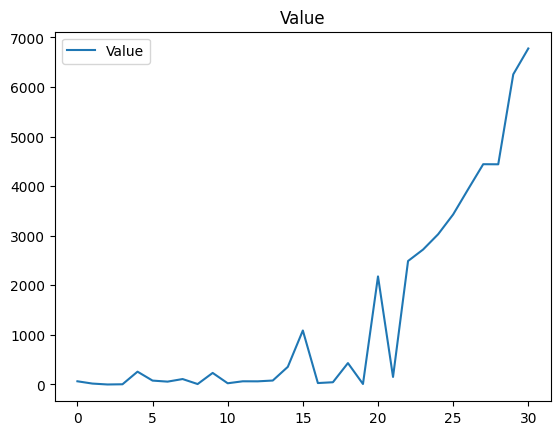

In [4]:
df = pd.DataFrame(outputs5, columns = ['Value'], index = range(outputs5.size))
plot = df.plot(title="Value")

## 5.2 Scatter plot - observations (3D)

In [ ]:
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=X[:, 3], s = abs(y)*10, cmap='viridis', alpha=0.7)

fig.colorbar(sc, label='4th Dimension (Color)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

# 6. Surrogate function

In [7]:
#Define kernel used
kernel_best_Q5 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.5, 2.5, 2.5, 1.5], nu=2.5, length_scale_bounds=(1e-3, 1e8))

#Initialize Gaussian Process Regressor
gp = GaussianProcessRegressor(
    kernel=kernel_best_Q5,
    n_restarts_optimizer=50,
    alpha=1e-3,
    random_state=42,
    normalize_y=False)

# Fit to data
gp.fit(X, y)

#Print the kernel to check if the value of optimized kernel is normal 
print("Optimized kernel:", gp.kernel_)

Optimized kernel: 4.08**2 * Matern(length_scale=[2.13, 1.7, 1.01, 34.8], nu=2.5)


# 7. Acquisition function

## 7.1 Differential Evolution (applicable when trusted region is not yet found)

In [ ]:
def hybrid_ucb(X, gp, kappa=0.1, alpha=0.5):
    mu, sigma = gp.predict(X, return_std=True)
    return alpha * mu + (1 - alpha) * (mu + kappa * sigma)


def optimize_acquisition_global(acquisition_func, gp, bounds, kappa=4.0, maxiter=100, popsize=30):
    # Objective to minimize (negative because DE minimizes)
    def objective(x):
        x = np.array(x).reshape(1, -1)
        return -acquisition_func(x, gp, kappa=kappa)[0]

    # Differential Evolution global optimization
    result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=maxiter,
        popsize=popsize,
        polish=True,       # refine the result locally at the end
        disp=True           # print optimization progress
    )

    x_next = result.x
    best_val = -result.fun
    return x_next, best_val

In [ ]:
bounds = [(0, 1), (0, 1), (0, 1), (0 ,1)]

next_point1, best_val1 = optimize_acquisition_global(
        acquisition_func=hybrid_ucb,
        gp=gp,
        bounds=bounds,
        kappa=0.05,      # larger kappa → more exploration
        maxiter=20000,     # number of DE iterations
        popsize=5000      # population size
    )

# Optimize acquisition
print("Next query point (by UCB):", next_point1)

##  7.2 Trusted Region Local Refinement (applicable when trusted region is found)

In [9]:
# Acquisition helpers
def hybrid_ucb(X, gp, kappa=0.1, alpha=0.5):
    mu, sigma = gp.predict(np.atleast_2d(X), return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    return alpha * mu + (1 - alpha) * (mu + kappa * sigma)

def expected_improvement(X, gp, y_best, xi=0.0):
    X = np.atleast_2d(X)
    mu, sigma = gp.predict(X, return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    with np.errstate(divide='warn'):
        Z = (mu - y_best - xi) / sigma
        ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# bounded local box around x_best
def trust_region_bounds(x_best, bounds, frac=0.1, min_width=1e-6):
    bounds_arr = np.array(bounds)
    full_range = bounds_arr[:, 1] - bounds_arr[:, 0]
    half_width = np.maximum(frac * full_range / 2.0, min_width)
    local_bounds = []
    for i in range(len(bounds)):
        low = max(bounds[i][0], x_best[i] - half_width[i])
        high = min(bounds[i][1], x_best[i] + half_width[i])
        local_bounds.append((low, high))
    return local_bounds

# ---------------------------
# local exploitation
def local_refinement(x0, acquisition_func, gp, bounds_local, y_best=None,
                     method="L-BFGS-B", objective_on="EI", xi=0.0):
    dim = len(x0)

    # objective to minimize (negative acquisition)
    def obj_for_min(x):
        x = np.atleast_2d(x)
        if objective_on == "EI":
            val = expected_improvement(x, gp, y_best=y_best, xi=xi)[0]
        elif objective_on == "mean":
            mu, _ = gp.predict(x, return_std=True)
            val = mu.ravel()[0]
        elif objective_on == "hybrid_ucb":
            val = hybrid_ucb(x, gp, kappa=0.0, alpha=1.0)[0]  # pure mean
        else:
            val = acquisition_func(x, gp)[0]
        return -float(val)

    # run minimize with multiple restarts (small jitter)
    best_x = np.array(x0).copy()
    best_val = -obj_for_min(best_x)

    # attempts: base start + a few jittered starts
    starts = [best_x] + [np.clip(best_x + 1e-3 * np.random.randn(dim), 
                                 [b[0] for b in bounds_local], [b[1] for b in bounds_local])
                         for _ in range(5)]

    for s in starts:
        res = minimize(obj_for_min, s, bounds=bounds_local, method=method,
                       options={"maxiter": 200})
        if not res.success:
            # fallback: still consider evaluated point
            xcand = np.clip(res.x, [b[0] for b in bounds_local], [b[1] for b in bounds_local])
            val = -obj_for_min(xcand)
        else:
            xcand = res.x
            val = -res.fun

        if val > best_val:
            best_val = val
            best_x = xcand

    return np.asarray(best_x), float(best_val)

# Two-stage acquisition optimizer (global -> local-exploit near x_best)
def optimize_with_local_exploit(gp, bounds, x_best_obs, y_best_obs,
                                global_acq_func=hybrid_ucb,
                                global_kappa=2.0, global_n_restarts=3,
                                trust_frac=0.2, 
                                local_objective="EI", 
                                local_method="L-BFGS-B",
                                do_global=True,
                                random_seed=None):
    dim = len(bounds)
    if random_seed is not None:
        np.random.seed(random_seed)

    best_global_x = None
    best_global_val = -np.inf
    if do_global:
        def obj_global(x):
            return -global_acq_func(np.atleast_2d(x), gp, kappa=global_kappa)[0]

        res = differential_evolution(obj_global, bounds=bounds, maxiter=80, popsize=15, polish=True)
        best_global_x = res.x
        best_global_val = -res.fun

    local_bounds = trust_region_bounds(np.asarray(x_best_obs), bounds, frac=trust_frac)
    x_refined, val_refined = local_refinement(x0=np.asarray(x_best_obs),
                                              acquisition_func=global_acq_func,
                                              gp=gp,
                                              bounds_local=local_bounds,
                                              y_best=y_best_obs,
                                              method=local_method,
                                              objective_on=local_objective)

    # Decision: choose local exploitation if it has better acquisition than global candidate
    chosen_x = x_refined
    chosen_val = val_refined
    if do_global and best_global_val > val_refined:
        chosen_x = best_global_x
        chosen_val = best_global_val

    # Return diagnostics
    diagnostics = {
        "global_candidate": best_global_x,
        "global_val": float(best_global_val) if do_global else None,
        "local_candidate": x_refined,
        "local_val": float(val_refined),
        "chosen_x": chosen_x,
        "chosen_val": float(chosen_val),
        "local_bounds": local_bounds
    }

    return np.asarray(chosen_x), float(chosen_val), diagnostics


In [10]:
bounds = [(0,1),(0,1),(0,1),(0,1)]

# inputs of best observation
x_best_obs = np.array([0.875693, 1.000000, 1.000000, 1.000000])

# best observation
y_best_obs = 2.72216361

next_point, acq_val, diag = optimize_with_local_exploit(
    gp=gp,
    bounds=bounds,
    x_best_obs=x_best_obs,
    y_best_obs=y_best_obs,
    global_acq_func=hybrid_ucb,
    global_kappa=0.01,
    global_n_restarts=10,
    trust_frac=0.1,
    local_objective="mean",
    do_global=False,
    local_method = "Nelder-Mead"
)

print("Chosen next point:", next_point)
print("Diagnostics:", diag)


Chosen next point: [0.925693 1.       1.       1.      ]
Diagnostics: {'global_candidate': None, 'global_val': None, 'local_candidate': array([0.925693, 1.      , 1.      , 1.      ]), 'local_val': 2.8680388613175865, 'chosen_x': array([0.925693, 1.      , 1.      , 1.      ]), 'chosen_val': 2.8680388613175865, 'local_bounds': [(0.825693, 0.9256930000000001), (0.95, 1), (0.95, 1), (0.95, 1)]}
